In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import xgboost as xgb

s3_path = "s3://sagemaker-us-east-1-423351913024/output_26dd7386-ef5e-4ca1-8652-57e13d8b904d/part-00000-fd6c5348-e8fa-4e2d-b2e7-5c39fbc4fe78-c000.csv"
df = pd.read_csv(s3_path)

X = df.select_dtypes(include=['number']).drop(['retained'], axis=1, errors='ignore')
if 'custid' in X.columns:
    X = X.drop(['custid'], axis=1)

y = df['retained']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"AUC ROC Score: {auc_score:.4f}")

C:\Users\ivanp\PycharmProjects\guild-mle-projects\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


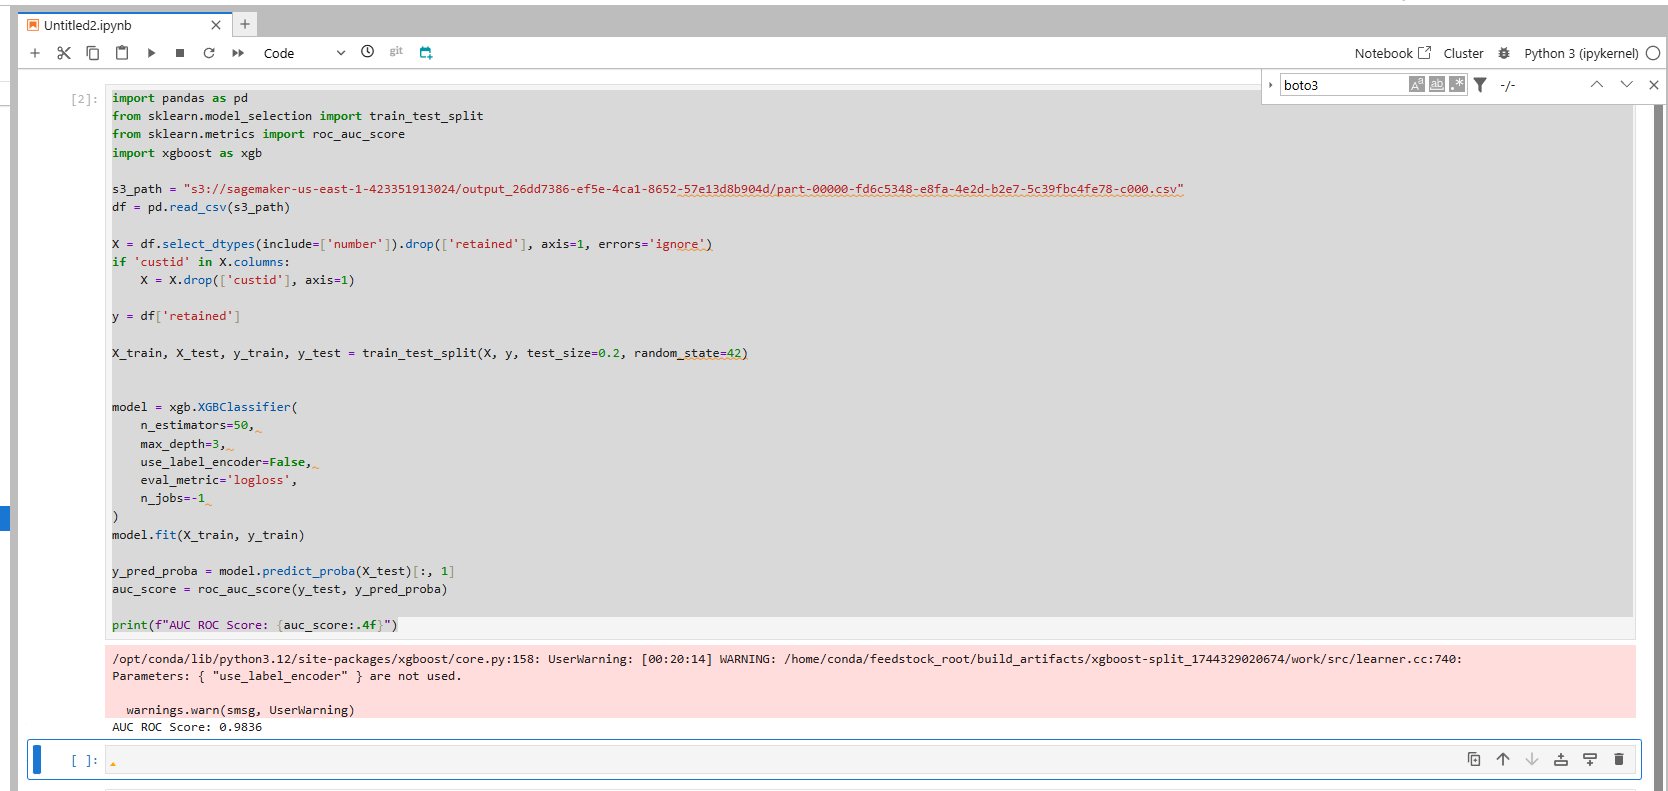